In [2]:
import torch
import matplotlib.pyplot as plt

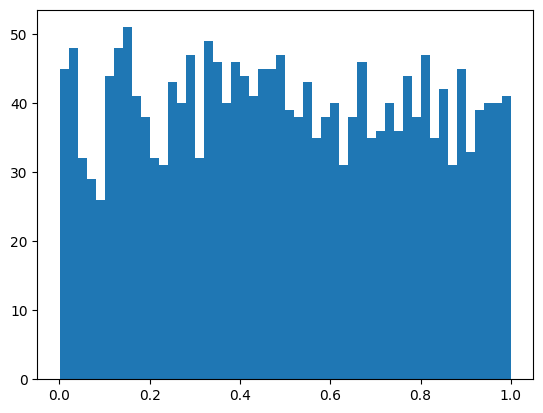

In [3]:
values = torch.rand(2000)
plt.hist(values.numpy(), bins=50);

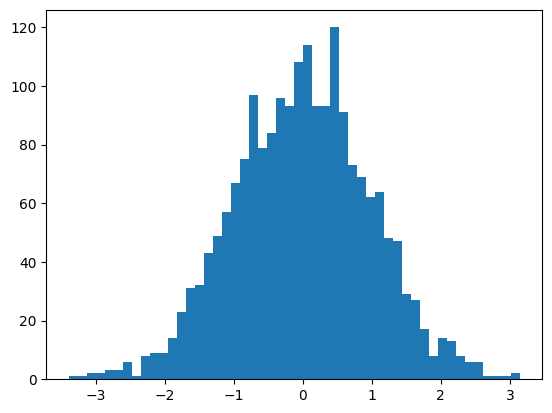

In [4]:
values = torch.randn(2000)
plt.hist(values.numpy(), bins=50);

In [5]:
torch.eye(5)

tensor([[1., 0., 0., 0., 0.],
        [0., 1., 0., 0., 0.],
        [0., 0., 1., 0., 0.],
        [0., 0., 0., 1., 0.],
        [0., 0., 0., 0., 1.]])

In [6]:
torch.full((5,4), 8)

tensor([[8, 8, 8, 8],
        [8, 8, 8, 8],
        [8, 8, 8, 8],
        [8, 8, 8, 8],
        [8, 8, 8, 8]])

In [7]:
houses = torch.tensor([
    [2, 65, 15, 285],
    [3, 95, 8, 425],
    [4, 120, 25, 380],
    [3, 88, 42, 295],
    [5, 180, 3, 675],
    [2, 58, 50, 245],
    ], dtype=torch.float32)

houses

tensor([[  2.,  65.,  15., 285.],
        [  3.,  95.,   8., 425.],
        [  4., 120.,  25., 380.],
        [  3.,  88.,  42., 295.],
        [  5., 180.,   3., 675.],
        [  2.,  58.,  50., 245.]])

In [8]:
x = torch.tensor([1.0, 2.0, 3.0])
y = torch.tensor([4.0, 5.0, 6.0])

# BASIC ARITHMETIC
print(x + y)        # Addition
print(x * y)        # Element-wise multiplication
print(x @ y)        # Dot product (matrix multiplication for 1D)

# AGGREGATIONS
print(x.sum())      # Sum all elements
print(x.mean())     # Average
print(x.max())      # Maximum value

tensor([5., 7., 9.])
tensor([ 4., 10., 18.])
tensor(32.)
tensor(6.)
tensor(2.)
tensor(3.)


In [9]:
import torch
import torch.nn.functional as F

x = torch.tensor([-2.0, -1.0, 0.0, 1.0, 2.0])

# RELU (MOST POPULAR) - SETS NEGATIVE VALUES TO 0
print(F.relu(x))        # tensor([0., 0., 0., 1., 2.])

# SIGMOID - NORMALISE VALUES BETWEEN 0 and 1
print(torch.sigmoid(x)) # tensor([0.12, 0.27, 0.50, 0.73, 0.88])

# TANH - NORMALISE VALUES BETWEEN -1 and 1
print(torch.tanh(x))    # tensor([-0.96, -0.76, 0.00, 0.76, 0.96])

tensor([0., 0., 0., 1., 2.])
tensor([0.1192, 0.2689, 0.5000, 0.7311, 0.8808])
tensor([-0.9640, -0.7616,  0.0000,  0.7616,  0.9640])


In [10]:
# DEFINE SINGLE VALUE TENSOR
# NOTICE WE ARE ENABLING GRADIENT TRACKING
x = torch.tensor(4.0, requires_grad=True)

# DEFINE FUNCTION f(x) = x² 
f = x ** 2

# TO CALCULATE GRADIENT WE CAN CALL .backward() function 
f.backward()

# WE CAN NOW CHECK THE GRADIENT (DERIVATIVE) AT OUR POINT x				
print(x.grad)  # 4.0

tensor(8.)


In [11]:
# DEFINE THREE TENSORS WITH GRADIENT TRACKING
x = torch.tensor(1.0, requires_grad=True)
y = torch.tensor(2.0, requires_grad=True)
z = torch.tensor(0.5, requires_grad=True)

# DEFINE FUNCTION f(x,y,z) = sin(x)·y² + e^z
f = torch.sin(x) * y**2 + torch.exp(z)

# CALCULATE GRADIENTS
f.backward()

# CHECK DERIVATIVES 
print(x.grad)  # cos(1) * 4   ≈ 2.16
print(y.grad)  # sin(1) * 2*2 ≈ 3.37
print(z.grad)  # e^0.5  ≈ 1.65

tensor(2.1612)
tensor(3.3659)
tensor(1.6487)


In [12]:
import torch
import torch.nn as nn
# CONTAINS ACTIVATION FUNCTIONS				
import torch.nn.functional as F
# PANDAS FOR LOADING CSV DATA				
import pandas as pd
# POPULAR LIBRARY FOR SPLITTING DATA			
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error
# OPTIONAL. FOR VISUALISATION
import matplotlib.pyplot as plt

In [13]:
df = pd.read_csv("london_houses_transformed.csv")

In [14]:
df

,area_sqft,bedrooms,bathrooms,receptions,type_Bungalow,type_Duplex,type_Flat / Apartment,type_House,type_Mews,type_New development,...,pc_W1W,pc_W2,pc_W3,pc_W4,pc_W5,pc_W6,pc_W8,pc_W9,pc_WD19,price
0,10100,10,10,10,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,9975000
1,2832,3,3,3,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,9950000
2,4876,6,6,6,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,9950000
3,5184,5,5,5,0,0,0,1,0,0,...,0,0,0,0,0,0,1,0,0,9950000
4,2782,2,2,2,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,9950000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3436,381,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,260000
3437,440,1,1,1,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,255000
3438,458,1,1,1,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,249999
3439,328,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,210000


In [15]:
X = df.drop("price", axis=1)
y = df["price"]

In [16]:
X_train_raw, X_test_raw, Y_train_raw, Y_test_raw = train_test_split(
    X.values, y.values, test_size=0.2, random_state=15
)

scaler_X = StandardScaler().fit(X_train_raw)
scaler_Y = StandardScaler().fit(Y_train_raw.reshape(-1, 1))

price_mean = scaler_Y.mean_[0]   
price_std  = scaler_Y.scale_[0]  

X_train = torch.FloatTensor(scaler_X.transform(X_train_raw))
X_test  = torch.FloatTensor(scaler_X.transform(X_test_raw))
Y_train = torch.FloatTensor(scaler_Y.transform(Y_train_raw.reshape(-1, 1)))  
Y_test  = torch.FloatTensor(scaler_Y.transform(Y_test_raw.reshape(-1, 1)))



In [17]:
X_test.size()

torch.Size([689, 87])

In [18]:
class Model(nn.Module):
    def __init__(self, in_features=87, h1=64, h2=32, output_features=1):
        super().__init__()
        self.fc1 = nn.Linear(in_features, h1)
        self.fc2 = nn.Linear(h1, h2)
        self.out = nn.Linear(h2, output_features)

    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.out(x)
        return x

model = Model()

In [19]:
epochs = 100
learning_rate = 0.01
torch.manual_seed(15)

losses = []


optimiser = torch.optim.Adam(model.parameters(), learning_rate)
loss_func = nn.MSELoss()

for i in range(epochs):
    optimiser.zero_grad()
    y_pred = model.forward(X_train)
    loss = loss_func(y_pred, Y_train)
    
    losses.append(loss.detach().numpy())

    if i % 10 == 0:
        print(f"Epoch {i} Loss: {loss.item():.4f}")
    
    optimiser.zero_grad()
    loss.backward()
    optimiser.step()

torch.save(model.state_dict(), "model.pth")

Epoch 0 Loss: 1.0034
Epoch 10 Loss: 0.3191
Epoch 20 Loss: 0.2059
Epoch 30 Loss: 0.1442
Epoch 40 Loss: 0.1222
Epoch 50 Loss: 0.1010
Epoch 60 Loss: 0.0917
Epoch 70 Loss: 0.0859
Epoch 80 Loss: 0.0812
Epoch 90 Loss: 0.0778


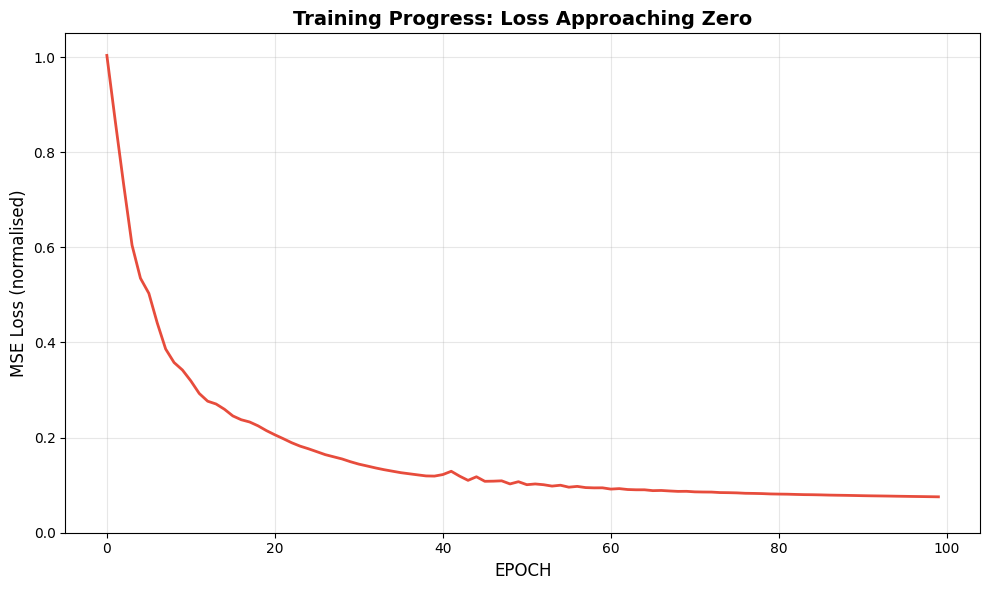

In [20]:
plt.figure(figsize=(10, 6))
plt.plot(losses, linewidth=2, color='#e74c3c')
plt.xlabel('EPOCH', fontsize=12)
plt.ylabel('MSE Loss (normalised)', fontsize=12)
plt.title('Training Progress: Loss Approaching Zero', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.ylim(bottom=0)  
plt.tight_layout()
plt.show()

In [21]:
model.eval()
with torch.no_grad():
    predictions = model(X_test)

    predictions_real = predictions * price_std + price_mean
    Y_test_real = Y_test * price_std + price_mean

    mae = mean_absolute_error(Y_test_real, predictions_real)
    mape = mean_absolute_percentage_error(Y_test_real, predictions_real) * 100

    pct_errors = torch.abs((Y_test_real - predictions_real) / Y_test_real) * 100

    within_10 = (pct_errors <= 10).sum().item()
    within_20 = (pct_errors <= 20).sum().item()
    total = len(Y_test_real)

print(f"\nOverall performance:")
print(f"  MAE:  £{mae:,.0f}")
print(f"  MAPE: {mape:.1f}%")
print(f"  Within 10%: {within_10}/{total} ({within_10/total*100:.0f}%)")
print(f"  Within 20%: {within_20}/{total} ({within_20/total*100:.0f}%)")


Overall performance:
  MAE:  £338,049
  MAPE: 19.8%
  Within 10%: 265/689 (38%)
  Within 20%: 458/689 (66%)
